# Observed transaction topology

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / "config.json").exists():
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"
assert (REPORTS / "run_manifest.json").exists(), "Run python -m fraudgraph.pipeline --download first"
manifest = json.loads((REPORTS / "run_manifest.json").read_text())
print("Evidence run:", manifest["run_id"])
def figure(name):
    display(Image(filename=str(REPORTS / "figures" / name)))


Evidence run: 20260923T163139886696Z


nodes                                                           203769
edges                                                           234355
directed                                                          True
isolated                                                             0
weak_components                                                     49
largest_component                                                 7880
strong_components                                               203769
degree_quantiles     {'min': 1.0, 'median': 2.0, 'p95': 4.0, 'p99':...
dtype: object

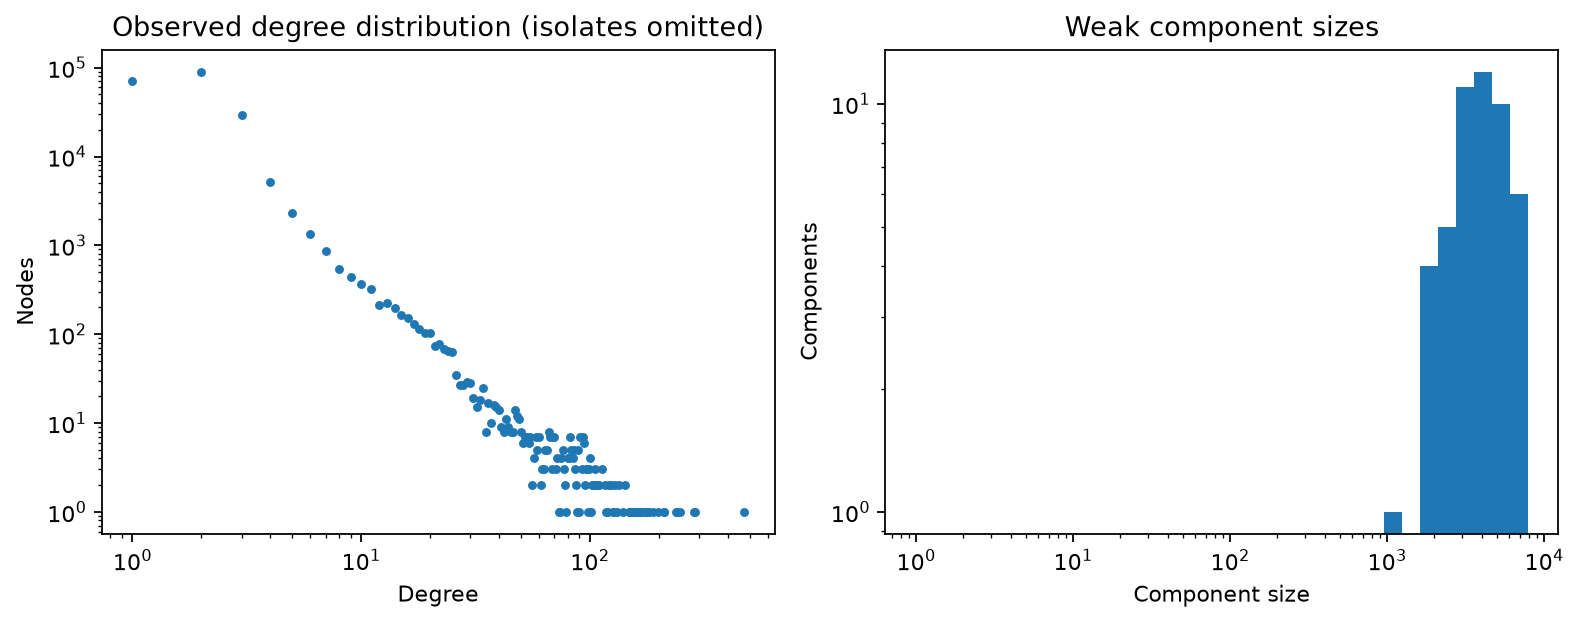

In [2]:
display(pd.Series(json.loads((REPORTS / "graph_validation.json").read_text())))
figure("graph_structure.png")

All released transaction edges lie within a time bucket. Components therefore do not provide a continuous bridge from training periods to future periods. A directed observed edge is not a claim that the released graph contains every transaction on Bitcoin.

,case,txId,time_step,class,score,baseline_score,neighbors_total,neighbors_shown
0,high_score_illicit,12662327,41,1,0.983907,0.893619,2,2
1,high_score_licit,72687354,42,2,0.955853,0.906812,2,2
2,graph_uplift,12661223,41,1,0.688997,0.299202,2,2


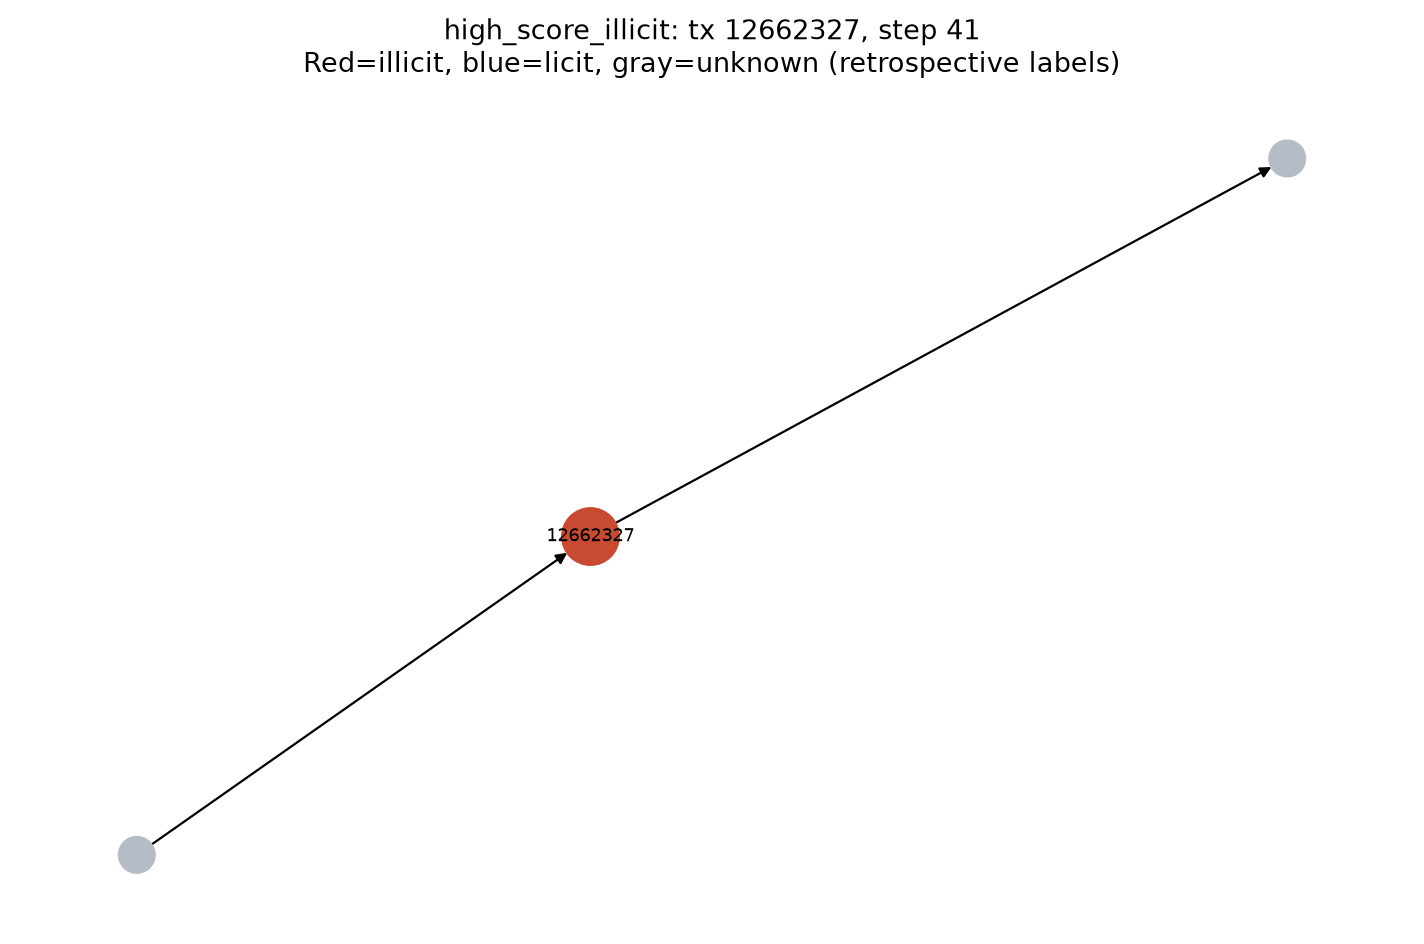

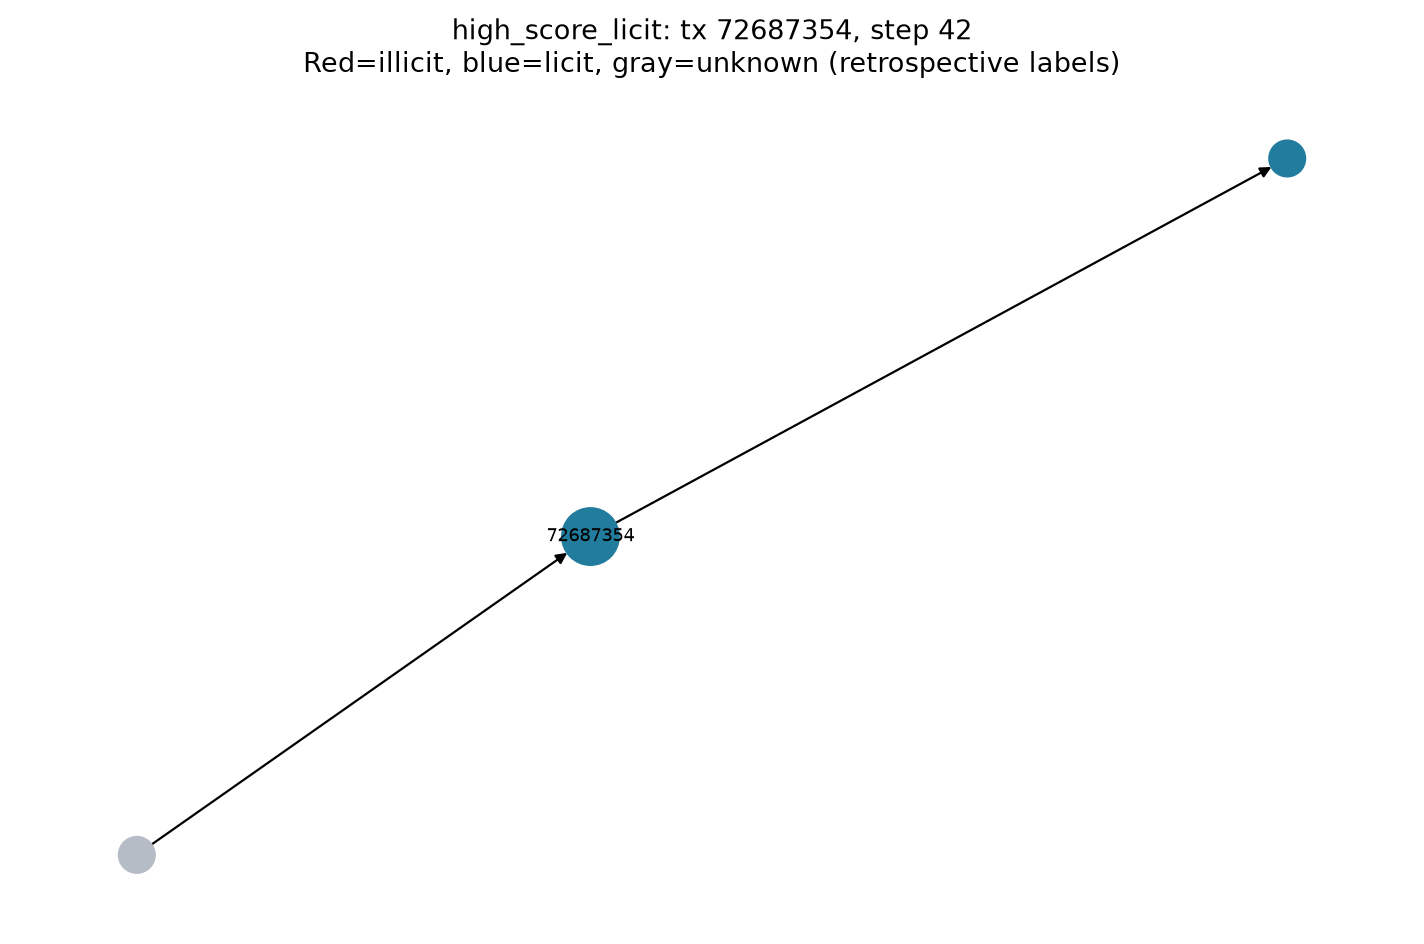

In [3]:
display(pd.read_csv(REPORTS / "cases.csv"))
figure("case_high_score_illicit.png")
figure("case_high_score_licit.png")

The case rule is reproducible: highest-score known illicit, highest-score known licit, and largest graph-model score uplift among known illicit test cases. Colors use retrospective outcomes only for explanation. Each view is capped at 40 nodes; HTML versions provide hover details and pan/zoom.